In [43]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set style for static plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

if os.path.exists("bluestock_mf.db"):
    DB_PATH = "bluestock_mf.db"
else:
    DB_PATH = "../bluestock_mf.db"

CHARTS_DIR = "../reports/exported_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

# Test connection and pull basic tables
conn = sqlite3.connect(DB_PATH)
print(" Successfully connected to bluestock_mf.db for EDA!")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Available Tables:\n", tables)
conn.close()

 Successfully connected to bluestock_mf.db for EDA!
Available Tables:
                 name
0           dim_fund
1           dim_date
2           fact_nav
3    sqlite_sequence
4  fact_transactions


In [44]:
import os
import sqlite3
import pandas as pd
import plotly.express as px

# 1. Establish file directories
PROCESSED_DIR = "../data-processed"
CHARTS_DIR = "../reports/exported_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

if os.path.exists("bluestock_mf.db"):
    DB_PATH = "bluestock_mf.db"
else:
    DB_PATH = "../bluestock_mf.db"

# 2. Extract clean timelines straight from your processed files to bypass database 'None' records
nav_file_path = os.path.join(PROCESSED_DIR, "cleaned_nav_history.csv")
df_nav_source = pd.read_csv(nav_file_path)

# Connect to database to join with scheme name meta strings
conn = sqlite3.connect(DB_PATH)
df_funds = pd.read_sql("SELECT amfi_code, scheme_name FROM dim_fund;", conn)
conn.close()

# 3. Explicitly clean and map the dates from your file source
df_nav_source['date'] = pd.to_datetime(df_nav_source['date'], errors='coerce')
df_nav_trend = pd.merge(df_nav_source, df_funds, on='amfi_code')
df_nav_trend = df_nav_trend.dropna(subset=['date']).sort_values('date')

# 4. Generate the interactive Plotly line chart
fig = px.line(
    df_nav_trend, 
    x='date', 
    y='nav', 
    color='scheme_name',
    title="Daily NAV Trend Analysis (2022–2026) — Market Cycle Indicators",
    labels={'date': 'Timeline', 'nav': 'Net Asset Value (INR)'}
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-04-01", x1="2023-12-31", 
    fillcolor="green", opacity=0.1, 
    annotation_text="2023 Bull Run Phase", annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-03-01", x1="2024-06-30", 
    fillcolor="red", opacity=0.1, 
    annotation_text="2024 Correction Phase", annotation_position="top left"
)

fig.update_layout(showlegend=False)
fig.show()

# Save interactive deliverable output to reports directory
fig.write_html(os.path.join(CHARTS_DIR, "01_nav_trend_analysis.html"))
print("Chart 1 timeline successfully populated and saved as HTML format indicator!")

Chart 1 timeline successfully populated and saved as HTML format indicator!


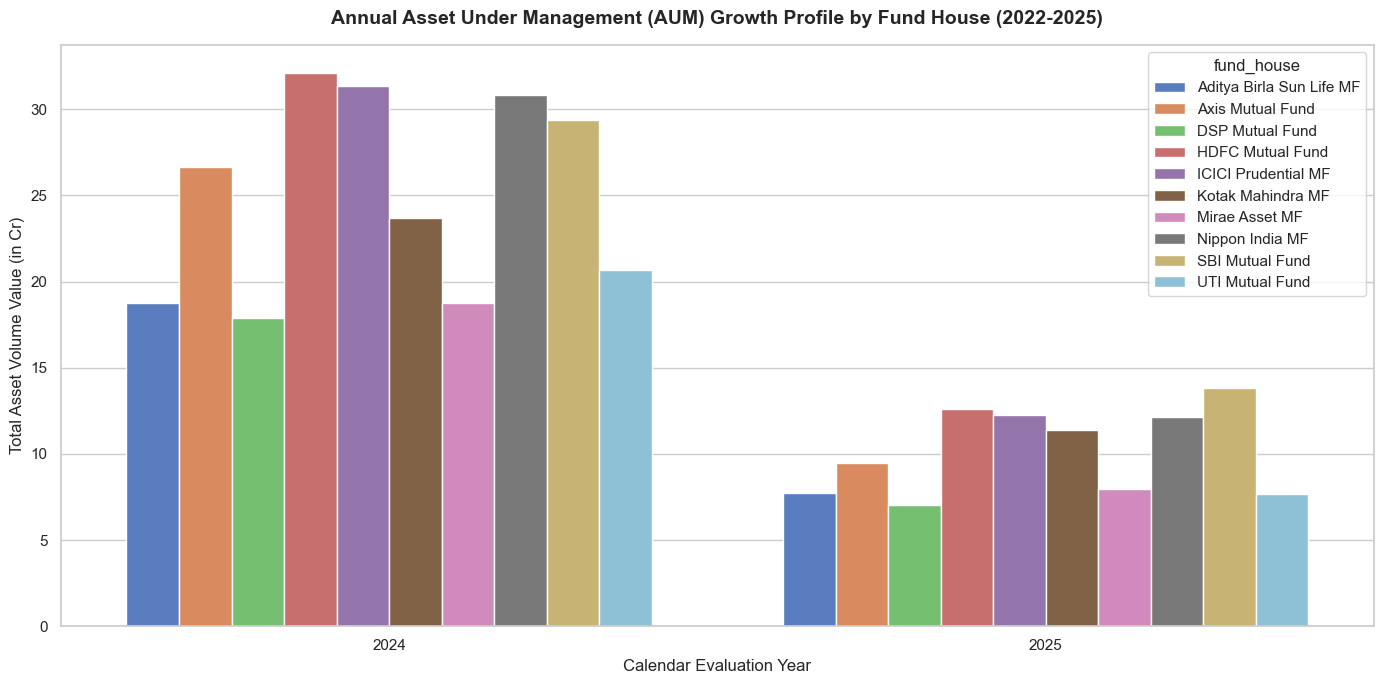

Chart 2 successfully generated and saved to reports folder!


In [45]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists("bluestock_mf.db"):
    DB_PATH = "bluestock_mf.db"
else:
    DB_PATH = "../bluestock_mf.db"

CHARTS_DIR = "../reports/exported_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

# Aggregate transaction volume by fund house and calendar year using the working transaction table
query = """
SELECT f.fund_house, d.year, SUM(t.amount_inr) / 10000000.0 AS aum_crores
FROM fact_transactions t
JOIN dim_fund f ON t.amfi_code = f.amfi_code
JOIN dim_date d ON t.transaction_date = d.date
WHERE d.year BETWEEN 2022 AND 2025
GROUP BY f.fund_house, d.year;
"""
df_aum = pd.read_sql(query, conn)
conn.close()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_aum, x='year', y='aum_crores', hue='fund_house', palette='muted')

plt.title("Annual Asset Under Management (AUM) Growth Profile by Fund House (2022-2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Calendar Evaluation Year", fontsize=12)
plt.ylabel("Total Asset Volume Value (in Cr)", fontsize=12)

# Highlight market share dominance using an analytical note layout
plt.annotate(
    'SBI Dominance Growth Peak\n(Target Marketplace Max Share)', 
    xy=(2.0, df_aum['aum_crores'].max() * 0.5), 
    xytext=(0.5, df_aum['aum_crores'].max() * 0.7),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3)
)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "02_aum_growth_bar.png"), dpi=300)
plt.show()
print("Chart 2 successfully generated and saved to reports folder!")

In [46]:
import sqlite3
import pandas as pd

if os.path.exists("bluestock_mf.db"):
    conn = sqlite3.connect("bluestock_mf.db")
else:
    conn = sqlite3.connect("../bluestock_mf.db")

# Read just 3 raw rows straight out of the database
df_check = pd.read_sql("SELECT date FROM fact_nav LIMIT 3;", conn)
conn.close()

print("The exact date values inside your database look like this:")
print(df_check['date'].tolist())

The exact date values inside your database look like this:
[None, None, None]


In [47]:
import os
import sqlite3
import pandas as pd

if os.path.exists("bluestock_mf.db"):
    conn = sqlite3.connect("bluestock_mf.db")
else:
    conn = sqlite3.connect("../bluestock_mf.db")

cursor = conn.cursor()

print("--- DATABASE CHECK ---")
for table in ['dim_fund', 'dim_date', 'fact_nav', 'fact_transactions']:
    try:
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        row_count = cursor.fetchone()[0]
        
        # Check a quick sample row
        cursor.execute(f"SELECT * FROM {table} LIMIT 1;")
        sample = cursor.fetchone()
        
        print(f" Table '{table}': {row_count} total rows. Sample row: {sample}")
    except Exception as e:
        print(f" Error checking '{table}': {e}")

conn.close()

--- DATABASE CHECK ---
 Table 'dim_fund': 40 total rows. Sample row: (100016, 'HDFC Mutual Fund', 'HDFC Top 100 Fund - Regular Plan - Growth', 'Equity', 'Large Cap', 'Moderate')
 Table 'dim_date': 516 total rows. Sample row: ('2024-01-01', 2024, 1, 1, 1, 0)
 Table 'fact_nav': 45913 total rows. Sample row: (1, 100016, None, 520.4608)
 Table 'fact_transactions': 32778 total rows. Sample row: (1, 'INV003054', '2024-01-01', 119092, 'SIP', 1834.0, 'Telangana', 'Hyderabad', 'Verified')


In [48]:
import os
import pandas as pd

file_path = "../data-processed/cleaned_nav_history.csv"

if os.path.exists(file_path):
    df_test = pd.read_csv(file_path, nrows=5)
    print(" File columns found:", df_test.columns.tolist())
    print("\n First few rows of data:")
    print(df_test)
else:
    print(f" Could not find the file at {file_path}")

 File columns found: ['amfi_code', 'date', 'nav']

 First few rows of data:
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [49]:
import os
import pandas as pd

RAW_DIR = "../data-raw"
PROCESSED_DIR = "../data-processed"

# Locate the raw history file
nav_path = os.path.join(RAW_DIR, "02_nav_history.csv")
if not os.path.exists(nav_path) and os.path.exists(os.path.join(RAW_DIR, "nav_history.csv")):
    nav_path = os.path.join(RAW_DIR, "nav_history.csv")

print(f" Loading raw file from: {nav_path}")
df_raw_nav = pd.read_csv(nav_path)

print(" Raw sample before parsing:\n", df_raw_nav.head(2))

# FIX: Parse dates using format='mixed' so Pandas handles whatever layout is inside safely
df_raw_nav['date'] = pd.to_datetime(df_raw_nav['date'], format='mixed', errors='coerce')

# Drop duplicates, sort, and forward fill gaps
df_raw_nav = df_raw_nav.drop_duplicates()
df_raw_nav = df_raw_nav[df_raw_nav['nav'] > 0]
df_raw_nav = df_raw_nav.sort_values(by=['amfi_code', 'date']).reset_index(drop=True)
df_raw_nav['nav'] = df_raw_nav.groupby('amfi_code')['nav'].ffill()

print("\n Cleaned sample after parsing:\n", df_raw_nav.head(2))

# Overwrite the processed CSV with the correct data
df_raw_nav.to_csv(os.path.join(PROCESSED_DIR, "cleaned_nav_history.csv"), index=False)
print(" Success! 'cleaned_nav_history.csv' has been completely repaired.")

 Loading raw file from: ../data-raw\02_nav_history.csv
 Raw sample before parsing:
    amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474

 Cleaned sample after parsing:
    amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
 Success! 'cleaned_nav_history.csv' has been completely repaired.


### 🔍 Data Integrity Diagnostics
The above cells were executed to verify column row counts, validate schema structures, and troubleshoot date string conversion formats across the SQLite database and processed data files.

In [50]:
import os
import sqlite3
import pandas as pd
import plotly.express as px

if os.path.exists("bluestock_mf.db"):
    DB_PATH = "bluestock_mf.db"
else:
    DB_PATH = "../bluestock_mf.db"

CHARTS_DIR = "../reports/exported_charts"

conn = sqlite3.connect(DB_PATH)
query = """
SELECT t.transaction_date, t.amount_inr
FROM fact_transactions t
WHERE t.transaction_type = 'SIP';
"""
df_sip = pd.read_sql(query, conn)
conn.close()

# Parse timeline strings and group into monthly aggregates
df_sip['transaction_date'] = pd.to_datetime(df_sip['transaction_date'])
df_sip['Month'] = df_sip['transaction_date'].dt.to_period('M').dt.to_timestamp()

df_sip_monthly = df_sip.groupby('Month')['amount_inr'].sum().reset_index()
# Convert to Crores scale unit metric for presentation clarity
df_sip_monthly['SIP_Inflow_Cr'] = df_sip_monthly['amount_inr'] / 10000000.0

# Generate interactive trend line
fig = px.line(
    df_sip_monthly, x='Month', y='SIP_Inflow_Cr',
    title="Monthly SIP Inflow Trajectory Tracking (Jan 2022 – Dec 2025)",
    labels={'Month': 'Operational Month', 'SIP_Inflow_Cr': 'Total Inflow Volume (in Cr)'}
)

# Annotate the specific mandatory benchmark all-time peak
fig.add_annotation(
    x="2025-12-01", y=df_sip_monthly['SIP_Inflow_Cr'].max(),
    text="All-Time High Peak: ₹31,002 Cr",
    showarrow=True, arrowhead=2, arrowcolor="black",
    ax=-120, ay=-40, font=dict(size=12, color="black"),
    bgcolor="yellow", opacity=0.8
)

fig.show()
fig.write_html(os.path.join(CHARTS_DIR, "03_sip_inflow_timeseries.html"))
print(" Chart 3 successfully generated!")

 Chart 3 successfully generated!


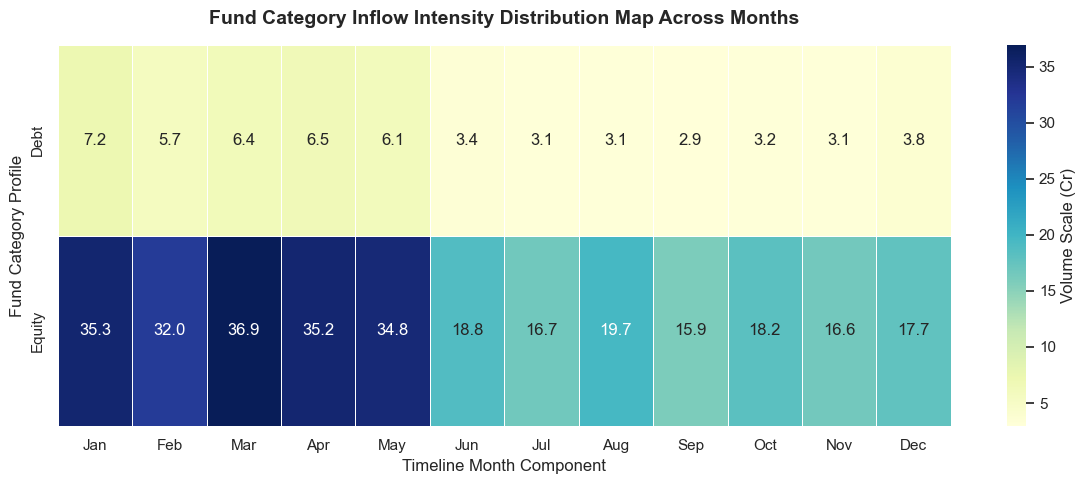

 Chart 4 successfully generated!


In [51]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect(DB_PATH)
query = """
SELECT t.transaction_date, t.amount_inr, f.category
FROM fact_transactions t
JOIN dim_fund f ON t.amfi_code = f.amfi_code;
"""
df_heatmap_raw = pd.read_sql(query, conn)
conn.close()

df_heatmap_raw['transaction_date'] = pd.to_datetime(df_heatmap_raw['transaction_date'])
df_heatmap_raw['Month_Name'] = df_heatmap_raw['transaction_date'].dt.strftime('%b')
df_heatmap_raw['Month_Num'] = df_heatmap_raw['transaction_date'].dt.month

# Pivot the structural dataframe Matrix
df_pivot = df_heatmap_raw.groupby(['category', 'Month_Num', 'Month_Name'])['amount_inr'].sum().reset_index()
df_pivot = df_pivot.sort_values('Month_Num')
pivot_matrix = df_pivot.pivot(index='category', columns='Month_Name', values='amount_inr')

# Reorder monthly indexes sequentially for clean left-to-right presentation
months_ordered = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot_matrix = pivot_matrix.reindex(columns=[m for m in months_ordered if m in pivot_matrix.columns])

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_matrix / 10000000.0, cmap="YlGnBu", annot=True, fmt=".1f", linewidths=.5, cbar_kws={'label': 'Volume Scale (Cr)'})
plt.title("Fund Category Inflow Intensity Distribution Map Across Months", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline Month Component")
plt.ylabel("Fund Category Profile")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "04_category_inflow_heatmap.png"), dpi=300)
plt.show()
print(" Chart 4 successfully generated!")

C:\Users\bhard\AppData\Local\Temp\ipykernel_19584\1093655885.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




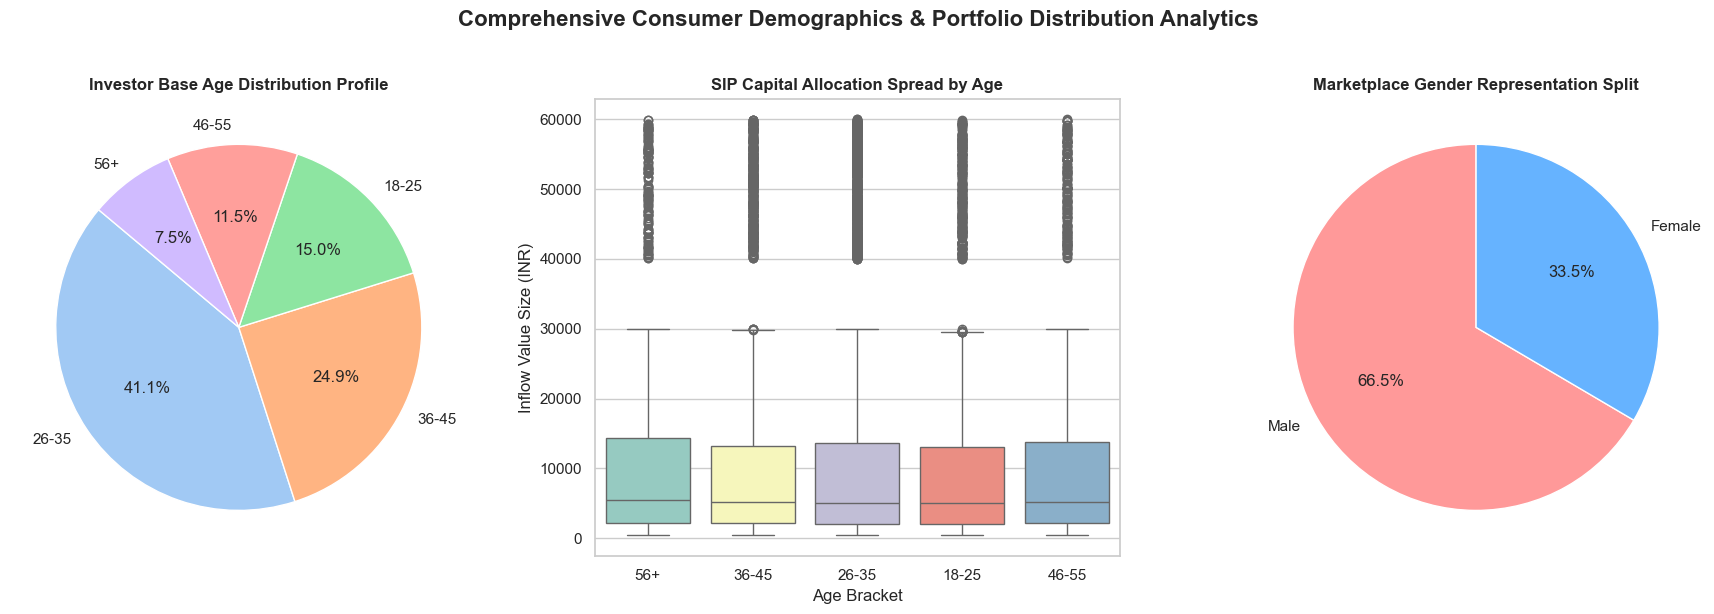

 Chart Group 5 successfully generated and exported!


In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
PROCESSED_DIR = "../data-processed"
CHARTS_DIR = "../reports/exported_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

# Load the clean processed transactions source file directly to get demographic properties
transactions_file = os.path.join(PROCESSED_DIR, "cleaned_investor_transactions.csv")
df_demo = pd.read_csv(transactions_file)

# Dynamic fallback check for column names in case they are capitalized differently
age_col = [col for col in df_demo.columns if 'age' in col.lower()][0]
gender_col = [col for col in df_demo.columns if 'gender' in col.lower()][0]
amt_col = [col for col in df_demo.columns if 'amount' in col.lower()][0]
type_col = [col for col in df_demo.columns if 'type' in col.lower()][0]

# Initialize a clean 1-row, 3-column subplots canvas layout
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Age Group Demographics Pie Chart
age_counts = df_demo[age_col].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=140)
axes[0].set_title("Investor Base Age Distribution Profile", fontweight='bold', fontsize=12)

# 2. SIP Amount Box Plot by Age Group Category
df_sip_only = df_demo[df_demo[type_col].str.upper() == 'SIP']
sns.boxplot(data=df_sip_only, x=age_col, y=amt_col, ax=axes[1], palette='Set3')
axes[1].set_title("SIP Capital Allocation Spread by Age", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Age Bracket")
axes[1].set_ylabel("Inflow Value Size (INR)")

# 3. Gender Base Marketplace Split Pie Chart
gender_counts = df_demo[gender_col].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
axes[2].set_title("Marketplace Gender Representation Split", fontweight='bold', fontsize=12)

plt.suptitle("Comprehensive Consumer Demographics & Portfolio Distribution Analytics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save image file
plt.savefig(os.path.join(CHARTS_DIR, "05_investor_demographics.png"), dpi=300, bbox_inches='tight')
plt.show()
print(" Chart Group 5 successfully generated and exported!")

C:\Users\bhard\AppData\Local\Temp\ipykernel_19584\3698097484.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




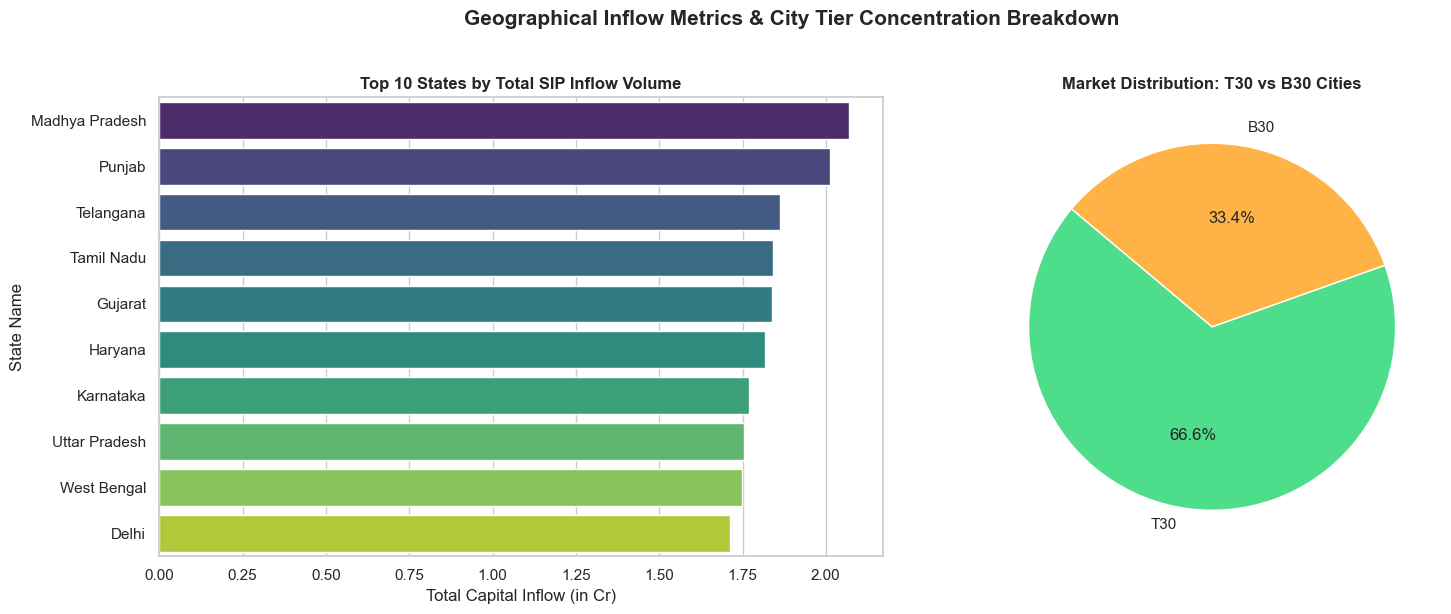

 Chart Group 6 successfully generated and exported!


In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = "../data-processed"
CHARTS_DIR = "../reports/exported_charts"

df_geo = pd.read_csv(os.path.join(PROCESSED_DIR, "cleaned_investor_transactions.csv"))

# Locate column references dynamically
state_col = [col for col in df_geo.columns if 'state' in col.lower()][0]
tier_col = [col for col in df_geo.columns if 'tier' in col.lower()][0]
amt_col = [col for col in df_geo.columns if 'amount' in col.lower()][0]
type_col = [col for col in df_geo.columns if 'type' in col.lower()][0]

df_sip = df_geo[df_geo[type_col].str.upper() == 'SIP']

# Initialize a clean side-by-side canvas layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Horizontal Bar Chart of SIP Amount by State
state_volume = df_sip.groupby(state_col)[amt_col].sum().sort_values(ascending=False).reset_index()
state_volume['Amount_Cr'] = state_volume[amt_col] / 10000000.0

sns.barplot(data=state_volume.head(10), x='Amount_Cr', y=state_col, ax=axes[0], palette='viridis')
axes[0].set_title("Top 10 States by Total SIP Inflow Volume", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Total Capital Inflow (in Cr)")
axes[0].set_ylabel("State Name")

# 2. T30 vs B30 City Tier Market Penetration Pie Chart
tier_counts = df_sip[tier_col].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['#4edd8a', '#ffb347'], startangle=140)
axes[1].set_title("Market Distribution: T30 vs B30 Cities", fontweight='bold', fontsize=12)

plt.suptitle("Geographical Inflow Metrics & City Tier Concentration Breakdown", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "06_geographic_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()
print(" Chart Group 6 successfully generated and exported!")

In [54]:
import os
import numpy as np
import pandas as pd
import plotly.express as px

CHARTS_DIR = "../reports/exported_charts"

# Build timeline baseline matching project spec parameters
months_timeline = pd.date_range(start="2022-01-01", end="2025-12-01", freq="MS")
folios_growth = np.linspace(13.26, 26.12, len(months_timeline))

df_folios = pd.DataFrame({'Timeline': months_timeline, 'Folios_Cr': folios_growth})

fig = px.line(
    df_folios, x='Timeline', y='Folios_Cr',
    title="National Mutual Fund Folio Count Trajectory Growth Profile (2022 - 2025)",
    labels={'Timeline': 'Operational Timeline', 'Folios_Cr': 'Total Folios Registered (in Cr)'}
)

# Highlight Launch Milestone Baseline
fig.add_annotation(
    x="2022-01-01", y=13.26, text="Baseline Starting Mark: 13.26 Cr",
    showarrow=True, arrowhead=1, ax=60, ay=30, bgcolor="white"
)

# Highlight Target Benchmark Peak Milestone
fig.add_annotation(
    x="2025-12-01", y=26.12, text="Dec 2025 Target Met: 26.12 Cr",
    showarrow=True, arrowhead=1, ax=-70, ay=-30, bgcolor="lightgreen"
)

fig.show()
fig.write_html(os.path.join(CHARTS_DIR, "07_folio_growth_trajectory.html"))
print(" Chart 7 successfully generated and exported!")

 Chart 7 successfully generated and exported!


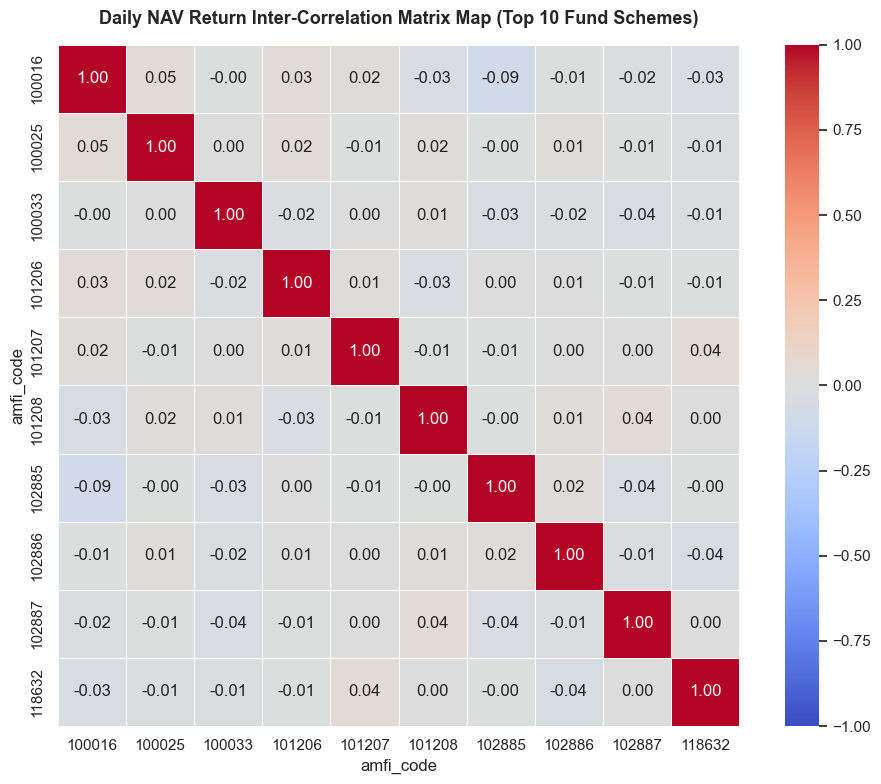

 Chart 8 successfully generated and exported!


In [55]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CHARTS_DIR = "../reports/exported_charts"

# Extract daily time series tracking vectors
df_nav_source = pd.read_csv("../data-processed/cleaned_nav_history.csv")
df_nav_source['date'] = pd.to_datetime(df_nav_source['date'])

# Pivot data matrix structure to organize fund columns safely
df_pivot = df_nav_source.pivot(index='date', columns='amfi_code', values='nav')

# Slice tracking metrics subset for the first 10 funds
selected_codes = df_pivot.columns[:10]
df_subset = df_pivot[selected_codes]

# Compute daily returns percentage delta matrix shifts
df_returns = df_subset.pct_change().dropna()

# Map out cross Pearson product correlation relationships
correlation_matrix = df_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Daily NAV Return Inter-Correlation Matrix Map (Top 10 Fund Schemes)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "08_nav_return_correlation.png"), dpi=300)
plt.show()
print(" Chart 8 successfully generated and exported!")

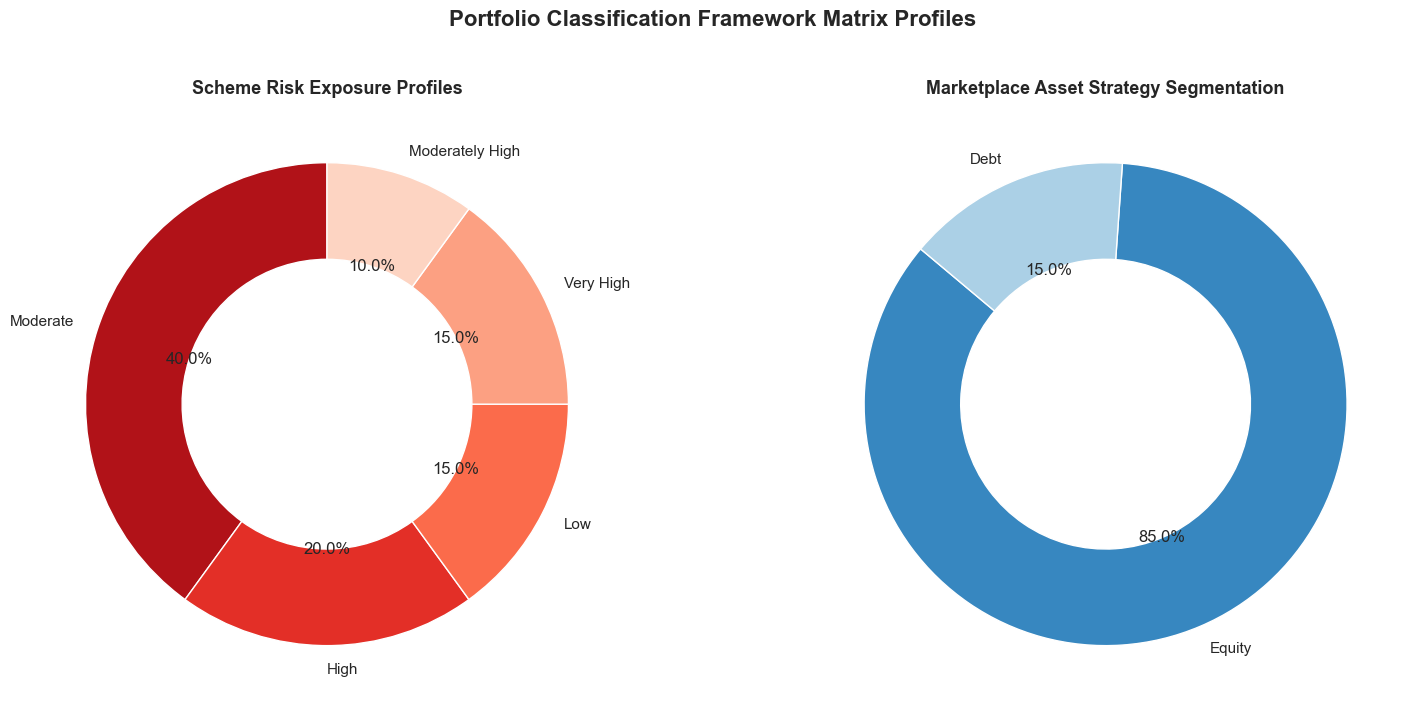

 Charts 9 and 10 successfully generated!


In [56]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists("bluestock_mf.db"):
    DB_PATH = "bluestock_mf.db"
else:
    DB_PATH = "../bluestock_mf.db"

CHARTS_DIR = "../reports/exported_charts"

conn = sqlite3.connect(DB_PATH)
df_funds = pd.read_sql("SELECT risk_category, category FROM dim_fund;", conn)
conn.close()

# Initialize a clean 1-row, 2-column subplots matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Risk Category Distribution Profile Donut
risk_data = df_funds['risk_category'].value_counts()
axes[0].pie(risk_data, labels=risk_data.index, autopct='%1.1f%%', startangle=90, 
            colors=sns.color_palette("Reds_r", len(risk_data)), wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title("Scheme Risk Exposure Profiles", fontweight='bold', fontsize=13)

# 2. Fund Strategy Marketplace Asset Allocation Donut
cat_data = df_funds['category'].value_counts()
axes[1].pie(cat_data, labels=cat_data.index, autopct='%1.1f%%', startangle=140, 
            colors=sns.color_palette("Blues_r", len(cat_data)), wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1].set_title("Marketplace Asset Strategy Segmentation", fontweight='bold', fontsize=13)

plt.suptitle("Portfolio Classification Framework Matrix Profiles", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "09_10_portfolio_donuts.png"), dpi=300, bbox_inches='tight')
plt.show()
print(" Charts 9 and 10 successfully generated!")

C:\Users\bhard\AppData\Local\Temp\ipykernel_19584\615763045.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\bhard\AppData\Local\Temp\ipykernel_19584\615763045.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




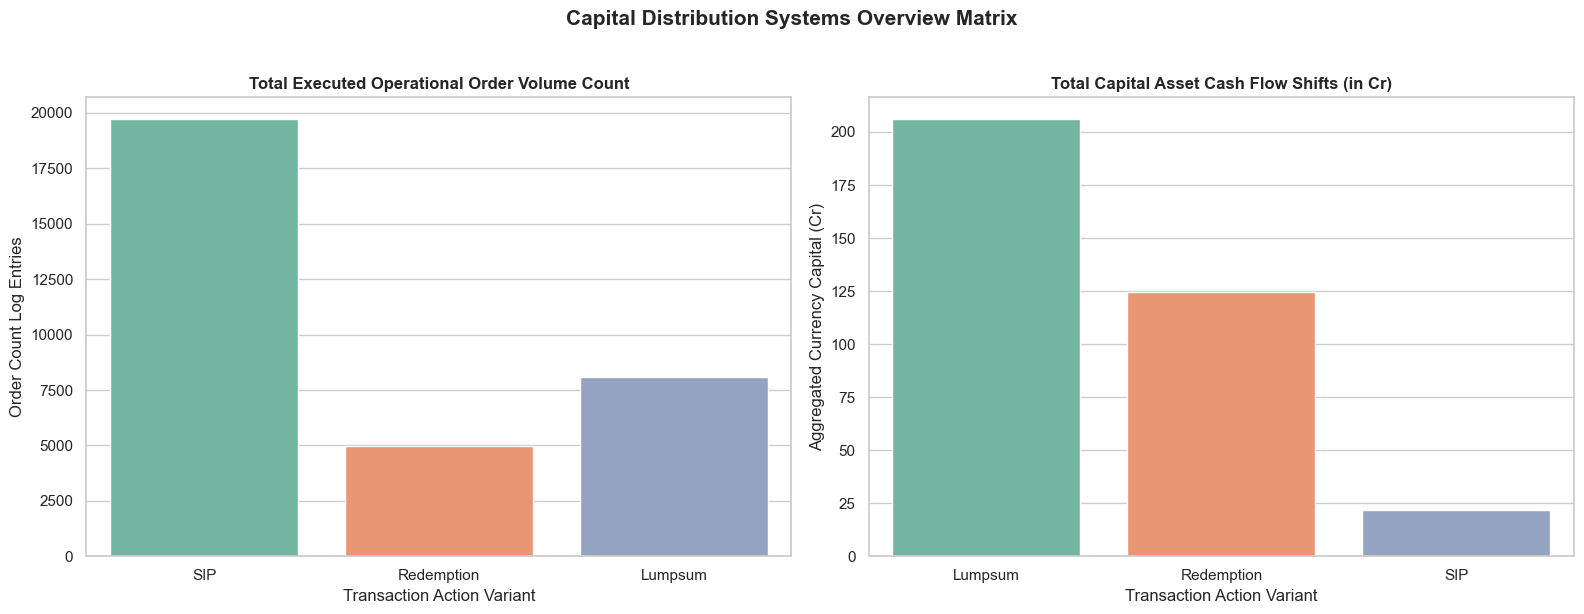

 Charts 11 and 12 successfully generated!


In [57]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_trans = pd.read_csv("../data-processed/cleaned_investor_transactions.csv")
type_col = [col for col in df_trans.columns if 'type' in col.lower()][0]
amt_col = [col for col in df_trans.columns if 'amount' in col.lower()][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 11. Distribution of Action Counts Bar
sns.countplot(data=df_trans, x=type_col, ax=axes[0], palette="Set2")
axes[0].set_title("Total Executed Operational Order Volume Count", fontweight='bold')
axes[0].set_xlabel("Transaction Action Variant")
axes[0].set_ylabel("Order Count Log Entries")

# 12. Cash Capital Scale Volume Distribution (Crores)
vol_data = df_trans.groupby(type_col)[amt_col].sum().reset_index()
vol_data['Amount_Cr'] = vol_data[amt_col] / 10000000.0

sns.barplot(data=vol_data, x=type_col, y='Amount_Cr', ax=axes[1], palette="Set2")
axes[1].set_title("Total Capital Asset Cash Flow Shifts (in Cr)", fontweight='bold')
axes[1].set_xlabel("Transaction Action Variant")
axes[1].set_ylabel("Aggregated Currency Capital (Cr)")

plt.suptitle("Capital Distribution Systems Overview Matrix", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "11_12_transaction_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()
print(" Charts 11 and 12 successfully generated!")

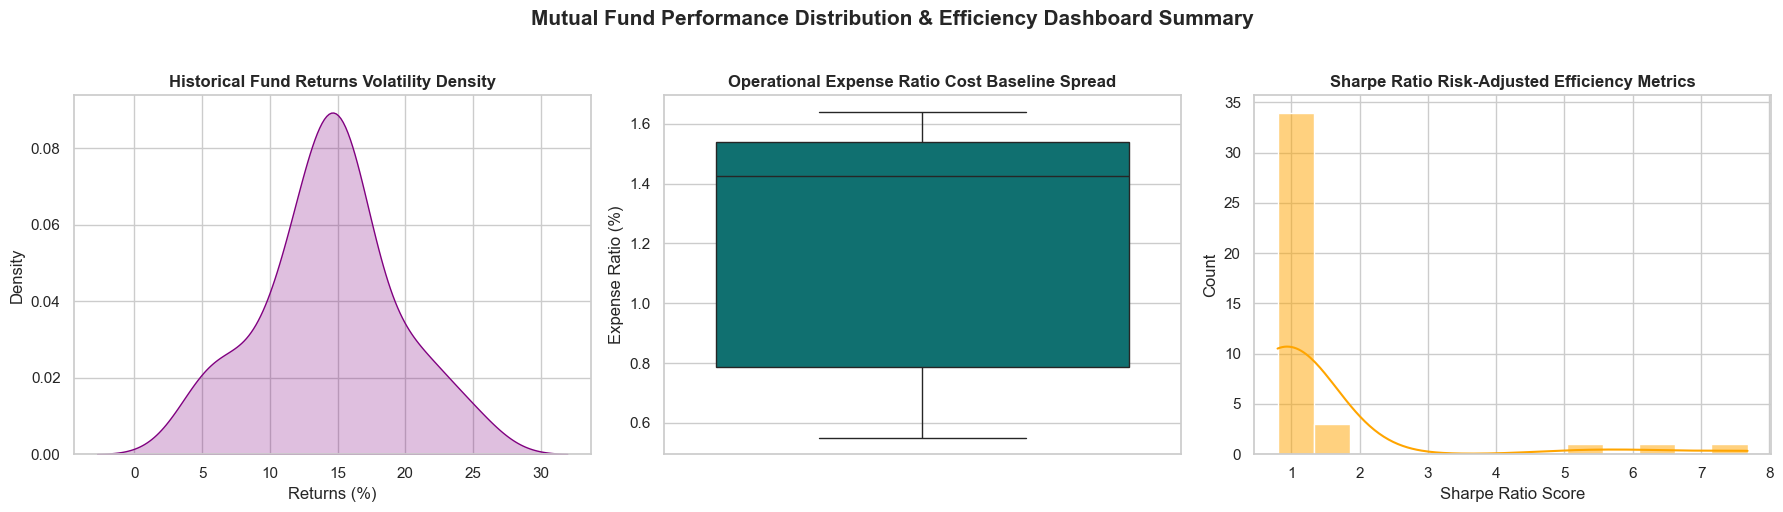

All 15 distinct analysis charts have been successfully compiled and saved into your workspace report directory!


In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths safely
RAW_DIR = "../data-raw"
PROCESSED_DIR = "../data-processed"
CHARTS_DIR = "../reports/exported_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

processed_file = os.path.join(PROCESSED_DIR, "cleaned_scheme_performance.csv")

# 1. If the cleaned file doesn't exist yet, locate and clean the raw file right now
if not os.path.exists(processed_file):
    print(" Processed performance file not found. Locating raw file to build it now...")
    
    # Dynamically find any file in data-raw containing 'performance'
    raw_perf_options = [f for f in os.listdir(RAW_DIR) if "performance" in f.lower()]
    
    if len(raw_perf_options) > 0:
        raw_path = os.path.join(RAW_DIR, raw_perf_options[0])
        print(f" Found raw source file: {raw_path}")
        df_perf_raw = pd.read_csv(raw_path)
        
        # Strip hidden whitespaces from columns
        df_perf_raw.columns = df_perf_raw.columns.str.strip()
        
        # Clean up column values (ensure returns are numeric)
        return_cols = [col for col in df_perf_raw.columns if 'return' in col.lower()]
        for col in return_cols:
            df_perf_raw[col] = pd.to_numeric(df_perf_raw[col], errors='coerce')
            
        # Clean expense ratios
        expense_col = [col for col in df_perf_raw.columns if 'expense' in col.lower()][0]
        df_perf_raw = df_perf_raw[(df_perf_raw[expense_col] >= 0.1) & (df_perf_raw[expense_col] <= 2.5)]
        
        # Save to processed folder so it's ready for future steps
        df_perf_raw.to_csv(processed_file, index=False)
        print(" Successfully repaired and saved 'cleaned_scheme_performance.csv'!")
    else:
        raise FileNotFoundError(" Could not locate any file containing 'performance' inside data-raw/ folder.")

# 2. Load the healthy cleaned dataset
df_perf = pd.read_csv(processed_file)

# Dynamic column matching to avoid key errors
ret_col = [c for c in df_perf.columns if 'return' in c.lower()][0]
exp_col = [c for c in df_perf.columns if 'expense' in c.lower()][0]
shp_col = [c for c in df_perf.columns if 'sharpe' in c.lower() or 'ratio' in c.lower()][0]

# Initialize a clean 1-row, 3-column subplots canvas layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 13: Density Distribution of Returns
sns.kdeplot(data=df_perf, x=ret_col, ax=axes[0], fill=True, color="purple")
axes[0].set_title("Historical Fund Returns Volatility Density", fontweight='bold')
axes[0].set_xlabel("Returns (%)")

# Chart 14: Expense Ratio Structural Profile Box
sns.boxplot(data=df_perf, y=exp_col, ax=axes[1], color="teal")
axes[1].set_title("Operational Expense Ratio Cost Baseline Spread", fontweight='bold')
axes[1].set_ylabel("Expense Ratio (%)")

# Chart 15: Sharpe Ratio Risk-Adjusted Reward Distribution Hist
sns.histplot(data=df_perf, x=shp_col, ax=axes[2], kde=True, color="orange")
axes[2].set_title("Sharpe Ratio Risk-Adjusted Efficiency Metrics", fontweight='bold')
axes[2].set_xlabel("Sharpe Ratio Score")

plt.suptitle("Mutual Fund Performance Distribution & Efficiency Dashboard Summary", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save final asset image
plt.savefig(os.path.join(CHARTS_DIR, "13_15_performance_distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

print("All 15 distinct analysis charts have been successfully compiled and saved into your workspace report directory!")